# Part 3 - EDA and Modelling Notebook

Goal: forecast daily `Revenue` for `2023-01-01` to `2024-07-01` using only the provided competition data.

This notebook is the machine-learning walkthrough for the current pipeline. It covers:

- sales time-series EDA,
- auxiliary-table coverage and usable signals,
- leakage-safe feature engineering,
- walk-forward validation,
- model comparison including LightGBM, XGBoost, and an MLP benchmark,
- final submission generation.

Important constraint: the auxiliary tables stop in 2022. For the 2023-2024 forecast horizon, raw future orders, traffic, promos, returns, shipments, and inventory are unavailable. These tables can only be used after conversion into date-based priors such as historical seasonal means and long lags.

## 0. Setup

In [24]:
from pathlib import Path
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Keep sklearn / LightGBM from opening too many threads on Windows notebooks.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
SUB_DIR = ROOT / "submissions"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT

WindowsPath('c:/Users/Admin/Documents/VIN Datathon')

In [ ]:
from src.validation import default_folds, metrics
from src.baselines import seasonal_naive_mean_2y
from src.features import build_feature_matrix
from src.aux_features import (
    COMMERCIAL_SEASONALITY_FEATURES,
    build_aux_daily,
    aux_feature_groups,
    build_aux_feature_matrix,
    build_commercial_seasonality_features,
)
from src.run_pipeline import evaluate_cv, fit_and_submit, load_sales

sales = load_sales()
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", parse_dates=["Date"])

print(sales.shape, sales.Date.min().date(), sales.Date.max().date())
print(sample_submission.shape, sample_submission.Date.min().date(), sample_submission.Date.max().date())

## 1. Data Coverage Audit

In [26]:
date_columns = {
    "sales": "Date",
    "sample_submission": "Date",
    "customers": "signup_date",
    "orders": "order_date",
    "shipments": "ship_date",
    "returns": "return_date",
    "reviews": "review_date",
    "inventory": "snapshot_date",
    "web_traffic": "date",
    "promotions": "start_date",
}

coverage_rows = []
for table, date_col in date_columns.items():
    path = DATA_DIR / f"{table}.csv"
    if table == "sample_submission":
        path = DATA_DIR / "sample_submission.csv"
    df = pd.read_csv(path, parse_dates=[date_col])
    coverage_rows.append({
        "table": table,
        "rows": len(df),
        "date_col": date_col,
        "min_date": df[date_col].min(),
        "max_date": df[date_col].max(),
        "covers_test_start": df[date_col].max() >= sample_submission.Date.min(),
    })

coverage = pd.DataFrame(coverage_rows).sort_values("max_date")
coverage

,table,rows,date_col,min_date,max_date,covers_test_start
9,promotions,50,start_date,2013-01-31,2022-11-18,False
4,shipments,566067,ship_date,2012-07-04,2022-12-29,False
0,sales,3833,Date,2012-07-04,2022-12-31,False
2,customers,121930,signup_date,2012-01-17,2022-12-31,False
3,orders,646945,order_date,2012-07-04,2022-12-31,False
5,returns,39939,return_date,2012-07-11,2022-12-31,False
6,reviews,113551,review_date,2012-07-10,2022-12-31,False
7,inventory,60247,snapshot_date,2012-07-31,2022-12-31,False
8,web_traffic,3652,date,2013-01-01,2022-12-31,False
1,sample_submission,548,Date,2023-01-01,2024-07-01,True


Observation: the only table covering the test horizon is `sample_submission`, and the competition clarification says test-window `COGS` must not be used as a feature. All other tables end in 2022, so their future values are not available at inference time.

## 2. Sales Time-Series EDA

In [27]:
sales_eda = sales.copy()
sales_eda["year"] = sales_eda.Date.dt.year
sales_eda["month"] = sales_eda.Date.dt.month
sales_eda["dow"] = sales_eda.Date.dt.dayofweek
sales_eda["doy"] = sales_eda.Date.dt.dayofyear

expected_days = pd.date_range(sales.Date.min(), sales.Date.max(), freq="D")
missing_days = expected_days.difference(pd.DatetimeIndex(sales.Date))

summary = pd.Series({
    "rows": len(sales),
    "missing_calendar_days": len(missing_days),
    "null_revenue": sales.Revenue.isna().sum(),
    "non_positive_revenue": (sales.Revenue <= 0).sum(),
    "revenue_min": sales.Revenue.min(),
    "revenue_median": sales.Revenue.median(),
    "revenue_mean": sales.Revenue.mean(),
    "revenue_max": sales.Revenue.max(),
})
summary.to_frame("value")

,value
rows,"3,833.0000"
missing_calendar_days,0.0000
null_revenue,0.0000
non_positive_revenue,0.0000
revenue_min,"279,813.9400"
revenue_median,"3,647,303.9000"
revenue_mean,"4,286,584.0296"
revenue_max,"20,905,271.3500"


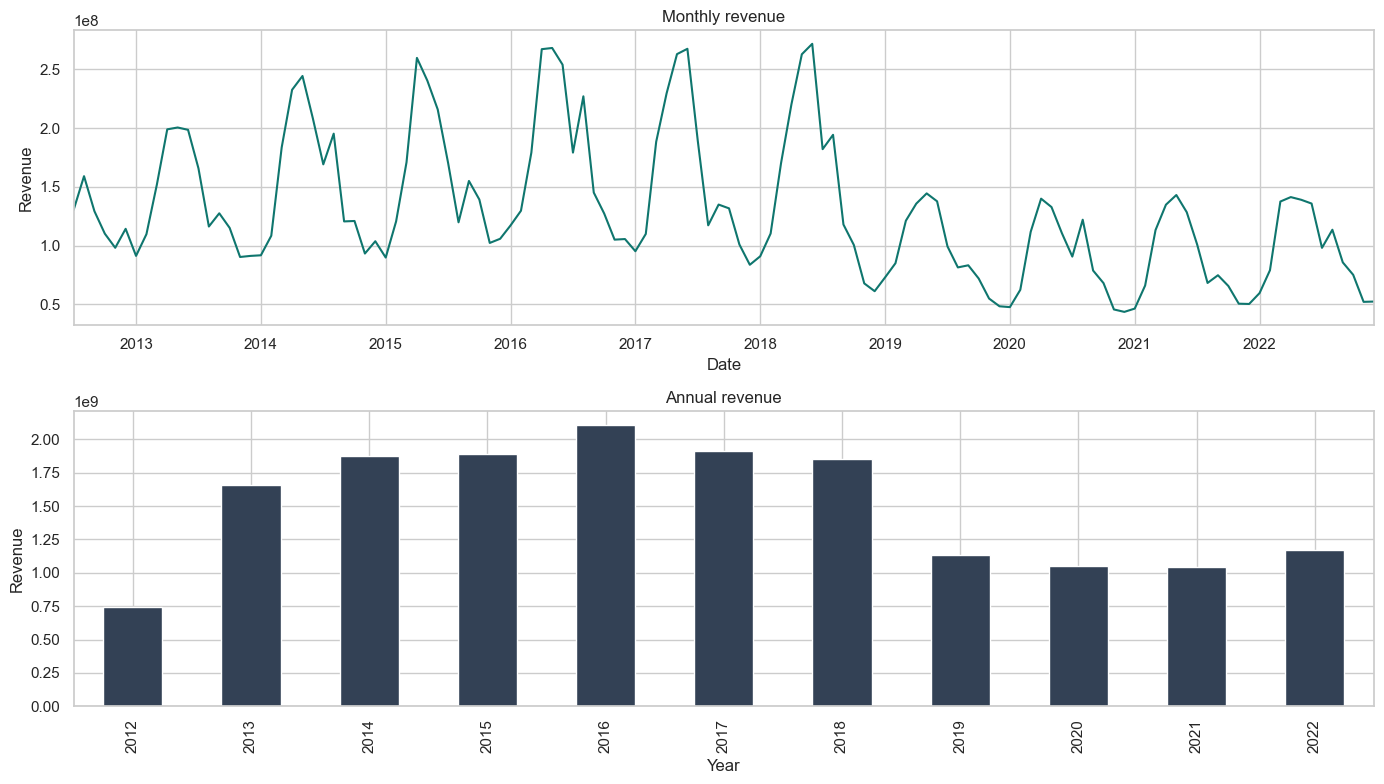

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

monthly = sales.set_index("Date").Revenue.resample("MS").sum()
monthly.plot(ax=axes[0], color="#0f766e")
axes[0].set_title("Monthly revenue")
axes[0].set_ylabel("Revenue")

annual = sales_eda.groupby("year").Revenue.sum()
annual.plot(kind="bar", ax=axes[1], color="#334155")
axes[1].set_title("Annual revenue")
axes[1].set_ylabel("Revenue")
axes[1].set_xlabel("Year")

plt.tight_layout()

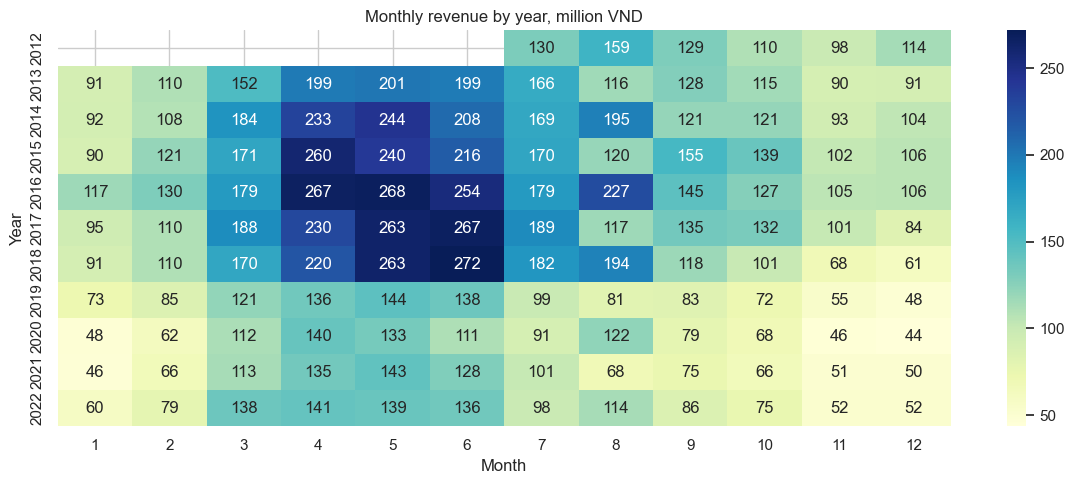

In [29]:
monthly_matrix = sales_eda.pivot_table(
    index="year", columns="month", values="Revenue", aggfunc="sum"
)

plt.figure(figsize=(12, 5))
sns.heatmap(monthly_matrix / 1_000_000, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly revenue by year, million VND")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()

In [30]:
lags = [1, 7, 30, 90, 180, 365, 548, 730]
acf = []
s = sales.set_index("Date").Revenue
for lag in lags:
    acf.append({"lag": lag, "corr": s.corr(s.shift(lag))})
pd.DataFrame(acf)

,lag,corr
0,1,0.8655
1,7,0.4920
2,30,0.6523
3,90,0.3277
4,180,-0.0442
5,365,0.7898
6,548,-0.0307
7,730,0.7179


Key interpretation:

- annual seasonality is strong,
- weekly structure matters and should be measured explicitly,
- short lags are predictive historically but unavailable deep into a 548-day direct forecast,
- long lags and seasonal lookup features are safer for validation and test,
- calendar variables such as month and weekday are cyclical, so they should not be treated as plain linear integers.

### 2.1 Cyclical Pattern Analysis

This subsection checks whether the data contains repeatable weekly and yearly cycles. For forecasting, that matters because a model usually learns better when calendar position is exposed explicitly rather than left implicit inside raw dates.

In [31]:
dow_profile = sales_eda.groupby("dow").Revenue.agg(["mean", "median", "count"])
dow_profile.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

month_profile = sales_eda.groupby("month").Revenue.agg(["mean", "median", "count"])

doy_profile = (
    sales_eda.assign(doy_365=np.where(sales_eda.doy > 365, 365, sales_eda.doy))
    .groupby("doy_365").Revenue.mean()
    .rolling(14, center=True, min_periods=7)
    .mean()
)

cyc_summary = pd.DataFrame({
    "metric": [
        "weekday_vs_weekend_ratio",
        "best_month_vs_worst_month_ratio",
        "lag_7_corr",
        "lag_365_corr",
    ],
    "value": [
        sales_eda.loc[sales_eda.dow < 5, "Revenue"].mean() / sales_eda.loc[sales_eda.dow >= 5, "Revenue"].mean(),
        month_profile["mean"].max() / month_profile["mean"].min(),
        s.corr(s.shift(7)),
        s.corr(s.shift(365)),
    ],
})

display(cyc_summary)
display(dow_profile)
display(month_profile)

,metric,value
0,weekday_vs_weekend_ratio,1.1040
1,best_month_vs_worst_month_ratio,2.6048
2,lag_7_corr,0.4920
3,lag_365_corr,0.7898


,mean,median,count
Mon,"4,311,034.6027","3,848,593.4400",547
Tue,"4,465,102.6433","3,925,730.2600",547
Wed,"4,680,064.8379","3,929,024.1800",548
Thu,"4,523,044.0528","3,629,496.9850",548
Fri,"4,046,389.7347","3,359,439.9850",548
Sat,"3,906,580.8389","3,384,605.3600",548
Sun,"4,073,853.6848","3,603,536.4800",547


,mean,median,count
month,,,
1,"2,591,154.6045","2,416,732.6950",310
2,"3,480,800.7782","3,242,762.8700",282
3,"4,928,185.4732","4,606,234.9900",310
4,"6,532,951.8821","5,795,217.0850",300
5,"6,575,416.3495","6,067,768.6100",310
6,"6,427,108.6523","5,826,463.1000",300
7,"4,659,789.3747","4,379,419.2450",338
8,"4,441,193.4900","3,646,382.1200",341
9,"3,797,825.6016","3,604,251.2000",330


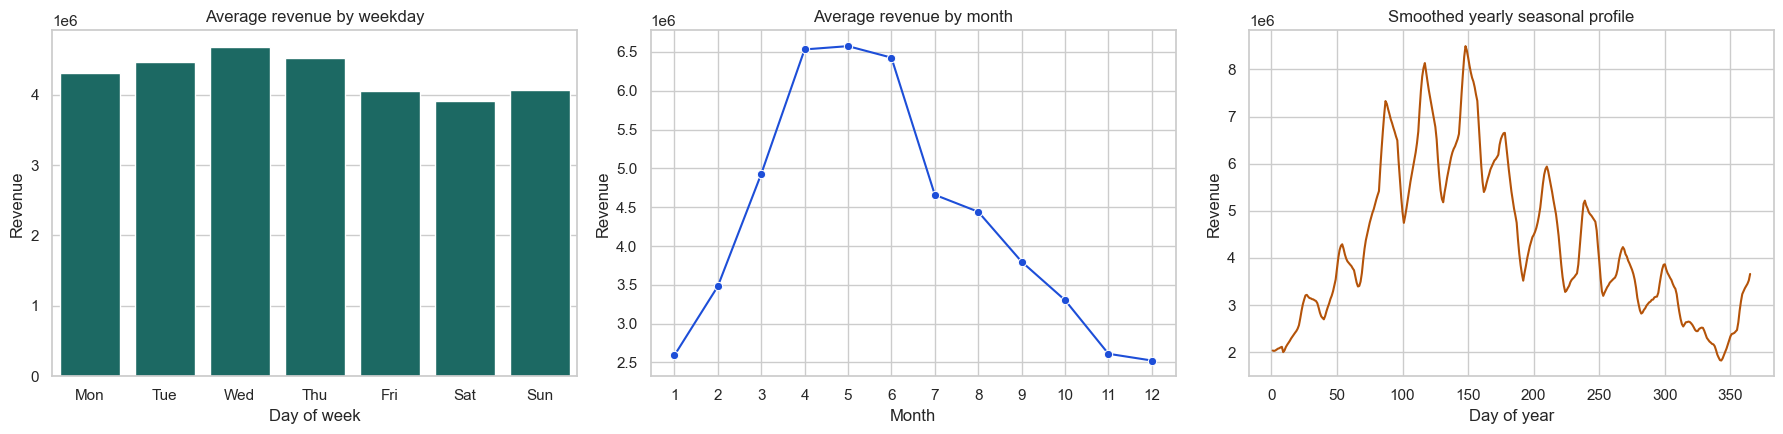

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.barplot(x=dow_profile.index, y=dow_profile["mean"].values, ax=axes[0], color="#0f766e")
axes[0].set_title("Average revenue by weekday")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Revenue")

sns.lineplot(x=month_profile.index, y=month_profile["mean"].values, marker="o", ax=axes[1], color="#1d4ed8")
axes[1].set_title("Average revenue by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue")
axes[1].set_xticks(range(1, 13))

sns.lineplot(x=doy_profile.index, y=doy_profile.values, ax=axes[2], color="#b45309")
axes[2].set_title("Smoothed yearly seasonal profile")
axes[2].set_xlabel("Day of year")
axes[2].set_ylabel("Revenue")

plt.tight_layout()

In [33]:
cyclic_demo = pd.DataFrame({"month": [12, 1, 2, 6], "dow": [6, 0, 1, 3]})
cyclic_demo["month_sin"] = np.sin(2 * np.pi * cyclic_demo["month"] / 12)
cyclic_demo["month_cos"] = np.cos(2 * np.pi * cyclic_demo["month"] / 12)
cyclic_demo["dow_sin"] = np.sin(2 * np.pi * cyclic_demo["dow"] / 7)
cyclic_demo["dow_cos"] = np.cos(2 * np.pi * cyclic_demo["dow"] / 7)
cyclic_demo

,month,dow,month_sin,month_cos,dow_sin,dow_cos
0,12,6,-0.0000,1.0000,-0.7818,0.6235
1,1,0,0.5000,0.8660,0.0000,1.0000
2,2,1,0.8660,0.5000,0.7818,0.6235
3,6,3,0.0000,-1.0000,0.4339,-0.9010


Interpretation for feature engineering:

- `month = 12` and `month = 1` are adjacent on the calendar, but raw integers make them look far apart.
- `dow = 6` and `dow = 0` have the same issue for Sunday and Monday.
- That is why the modelling pipeline uses cyclical encodings such as `month_sin`, `month_cos`, `doy_sin`, `doy_cos`, `dow_sin`, and `dow_cos` in [src/features.py](/c:/Users/Admin/Documents/VIN Datathon/src/features.py).
- Cyclical features capture calendar position, while long lags and seasonal lookup means capture expected revenue level.

## 3. Auxiliary Table EDA

In [34]:
aux_daily = build_aux_daily()
groups = aux_feature_groups(aux_daily)

print(aux_daily.shape)
pd.Series({name: len(cols) for name, cols in groups.items()}, name="n_raw_aux_columns")

(3833, 64)


volume                   11
marketing_web            11
mix_geo_product          16
ops_quality_inventory    14
all_aux                  52
Name: n_raw_aux_columns, dtype: int64

,corr_with_revenue
gross_sales,1.0000
net_item_sales,0.9921
payment_value,0.9921
unique_customers,0.9370
order_count,0.9359
units,0.9178
distinct_products,0.9113
shipments,0.8149
shipping_fee,0.5905
review_rows,0.5598


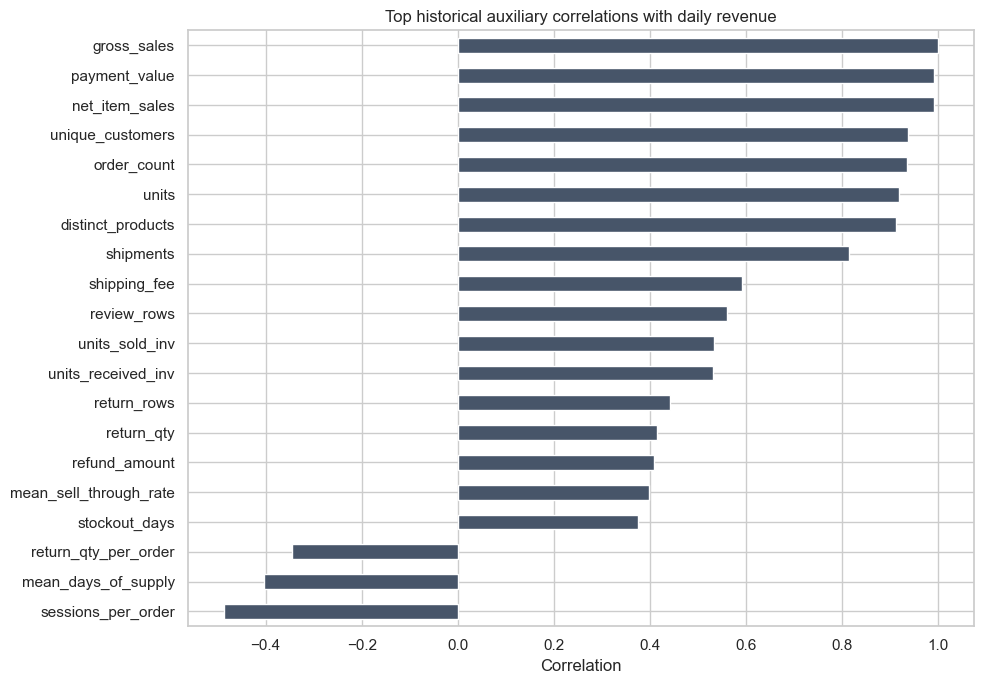

In [35]:
aux_corr = aux_daily.join(sales.set_index("Date").Revenue).corr(numeric_only=True)["Revenue"].drop("Revenue")
aux_corr = aux_corr.reindex(aux_corr.abs().sort_values(ascending=False).index)

display(aux_corr.head(25).to_frame("corr_with_revenue"))

plt.figure(figsize=(10, 7))
aux_corr.head(20).sort_values().plot(kind="barh", color="#475569")
plt.title("Top historical auxiliary correlations with daily revenue")
plt.xlabel("Correlation")
plt.tight_layout()

The high raw correlations are expected: actual order volume, units, payments, and shipments are close to realized revenue. They are explanatory, but they are not raw future features because those values are absent for the forecast horizon.

In [36]:
recent_aux = aux_daily.join(sales.set_index("Date").Revenue).loc["2019":].copy()
recent_aux["month"] = recent_aux.index.month

monthly_aux = recent_aux.groupby("month")[[
    "Revenue", "order_count", "units", "sessions", "avg_discount_rate",
    "active_promos", "return_qty", "avg_order_value"
]].mean()
monthly_aux

,Revenue,order_count,units,sessions,avg_discount_rate,active_promos,return_qty,avg_order_value
month,,,,,,,,
1,"1,829,234.2283",56.5000,276.7742,"15,455.3952",0.0080,0.0887,12.9839,"32,621.7525"
2,"2,590,154.6755",78.4159,379.3451,"22,691.6726",0.0229,0.4956,9.7257,"32,813.0591"
3,"3,901,817.2783",128.2339,616.1694,"32,022.6129",0.0468,0.4677,13.5161,"30,014.1372"
4,"4,598,619.4788",150.5583,716.6000,"43,309.3833",0.0608,0.5667,23.5833,"28,833.4229"
5,"4,511,012.0796",139.1371,660.9919,"40,290.0806",0.0000,0.0000,24.0323,"32,433.8269"
6,"4,271,649.1205",136.8000,648.7083,"42,301.5083",0.0358,0.2667,23.4417,"30,787.9453"
7,"3,138,949.9147",108.7984,513.4677,"32,747.0161",0.1150,0.7419,19.5726,"26,074.8361"
8,"3,107,932.0767",117.4516,557.0081,"36,629.4113",0.0049,0.5565,17.5484,"26,737.1749"
9,"2,689,355.6353",88.6917,421.7250,"26,106.8083",0.0953,1.0333,17.3167,"27,812.3166"


## 4. Leakage-Safe Feature Engineering

In [ ]:
fold = default_folds()[-1]
train = sales[sales.Date <= fold.train_end]
val = sales[fold.mask_val(sales.Date)]

X_sales_train = build_feature_matrix(train.Date, sales, as_of=fold.train_end)
X_sales_val = build_feature_matrix(val.Date, sales, as_of=fold.train_end)

raw_aux_cols = groups["all_aux"]
X_aux_train = build_aux_feature_matrix(train.Date, fold.train_end, raw_aux_cols, aux_daily=aux_daily)
X_aux_val = build_aux_feature_matrix(val.Date, fold.train_end, raw_aux_cols, aux_daily=aux_daily)
X_commercial_train = build_commercial_seasonality_features(train.Date, fold.train_end, aux_daily=aux_daily)
X_commercial_val = build_commercial_seasonality_features(val.Date, fold.train_end, aux_daily=aux_daily)

print("Commercial seasonality feature group:")
print(COMMERCIAL_SEASONALITY_FEATURES)

pd.DataFrame({
    "matrix": [
        "sales_features_train", "sales_features_val",
        "aux_features_train", "aux_features_val",
        "commercial_seasonality_train", "commercial_seasonality_val",
    ],
    "rows": [
        len(X_sales_train), len(X_sales_val),
        len(X_aux_train), len(X_aux_val),
        len(X_commercial_train), len(X_commercial_val),
    ],
    "columns": [
        X_sales_train.shape[1], X_sales_val.shape[1],
        X_aux_train.shape[1], X_aux_val.shape[1],
        X_commercial_train.shape[1], X_commercial_val.shape[1],
    ],
})

In [38]:
sales_feature_preview = X_sales_train.drop(columns=["Date"]).head(3)
aux_feature_preview = X_aux_train.head(3)

display(sales_feature_preview.iloc[:, :12])
display(aux_feature_preview.iloc[:, :12])

,year,month,day,dow,doy,week,quarter,is_weekend,is_month_start,is_month_end,month_sin,month_cos
0,2012,7,4,2,186,27,3,0,0,0,-0.5000,-0.8660
1,2012,7,5,3,187,27,3,0,0,0,-0.5000,-0.8660
2,2012,7,6,4,188,27,3,0,0,0,-0.5000,-0.8660


,aux_order_count_month_mean,aux_order_count_month_dow_mean,aux_order_count_doy_mean,aux_order_count_week_mean,aux_order_count_lag548,aux_order_count_lag730,aux_order_count_year1,aux_order_count_year2,aux_order_count_roll30_548,aux_order_count_roll30_730,aux_unique_customers_month_mean,aux_unique_customers_month_dow_mean
0,111.4946,130.0000,54.3333,117.1429,NaN,NaN,NaN,NaN,NaN,NaN,111.0000,129.2857
1,111.4946,133.7857,56.6667,117.1429,NaN,NaN,NaN,NaN,NaN,NaN,111.0000,133.0714
2,111.4946,127.0000,75.6667,117.1429,NaN,NaN,NaN,NaN,NaN,NaN,111.0000,126.5000


Feature design summary:

- target uses `log(Revenue)`,
- sales features include calendar, Tet, seasonal lookup, long lags, and rolling long-lag windows,
- auxiliary features are built as historical date priors only,
- no direct actual future `orders`, `traffic`, `returns`, `inventory`, or `promotions` values are used.

## 5. Walk-Forward Validation

In [39]:
pd.DataFrame([
    {
        "fold": f.name,
        "train_end": f.train_end,
        "val_start": f.val_start,
        "val_end": f.val_end,
        "val_days": (f.val_end - f.val_start).days + 1,
    }
    for f in default_folds()
])

,fold,train_end,val_start,val_end,val_days
0,fold1_2020H2-2021,2020-06-30,2020-07-01,2021-12-31,549
1,fold2_2021H2-2022,2021-06-30,2021-07-01,2022-12-31,549
2,fold3_test_proxy,2021-12-31,2022-01-01,2022-12-31,365


The notebook reads existing XGBoost CV artifacts by default so it opens quickly. Set `RUN_FULL_CV = True` to rerun model validation from the notebook. If no compatible artifact exists, the cell computes CV once and saves it to `outputs/xgboost_cv_results.csv`.

In [ ]:
RUN_FULL_CV = False

xgb_cv_path = OUT_DIR / "xgboost_cv_results.csv"
legacy_cv_path = OUT_DIR / "cv_results.csv"

if RUN_FULL_CV:
    cv_results = evaluate_cv(sales)
    cv_results.to_csv(xgb_cv_path, index=False)
elif xgb_cv_path.exists():
    cv_results = pd.read_csv(xgb_cv_path)
elif legacy_cv_path.exists():
    # Fallback for older runs. The current canonical artifact is xgboost_cv_results.csv.
    cv_results = pd.read_csv(legacy_cv_path)
else:
    print("No CV artifact found; running evaluate_cv(sales) once. This may take a few minutes.")
    cv_results = evaluate_cv(sales)
    cv_results.to_csv(xgb_cv_path, index=False)

cv_results.tail()

In [41]:
cv_summary = (
    cv_results.groupby("model")[["MAE", "RMSE", "R2", "MAPE"]]
    .mean()
    .sort_values("R2", ascending=False)
)
cv_summary

,MAE,RMSE,R2,MAPE
model,,,,
ensemble_hist_gbr_baseline,"594,614.9082","805,959.7597",0.7445,0.2245
gbr_log_target,"606,892.3024","833,222.0905",0.7266,0.2282
hist_gbm_log_target,"625,248.7068","847,697.3827",0.7163,0.2334
lightgbm_log_target,"628,974.3308","853,686.4870",0.7121,0.2353
lightgbm_all_aux_log_target,"636,495.9460","867,219.1797",0.7038,0.2391
lightgbm_top_aux_log_target,"640,042.2596","866,963.6557",0.7029,0.2446
seasonal_naive_mean2y,"705,507.1392","963,071.6824",0.6344,0.2706
mlp_deep_learning,"727,076.3484","979,607.8959",0.6205,0.2802
seasonal_naive_lag365,"837,704.0918","1,161,819.0015",0.5182,0.2786


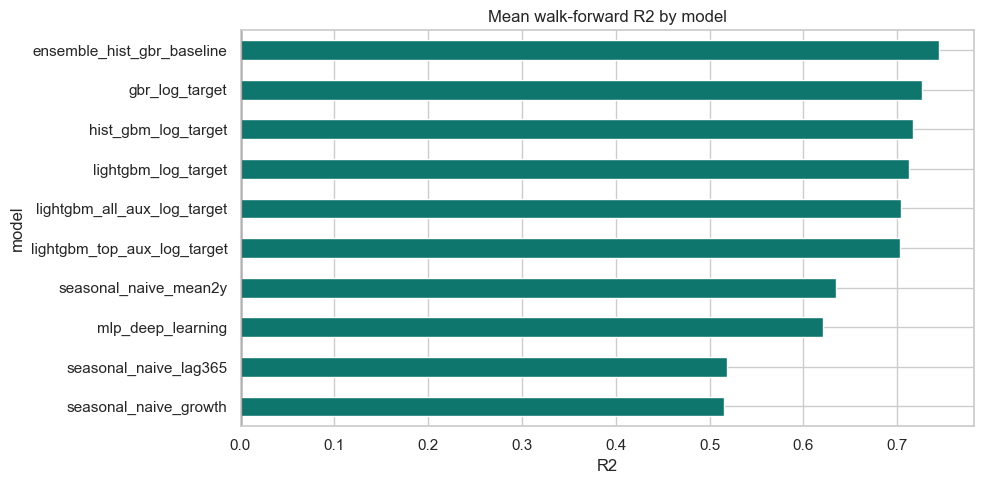

In [42]:
plt.figure(figsize=(10, 5))
cv_summary["R2"].sort_values().plot(kind="barh", color="#0f766e")
plt.axvline(0, color="black", linewidth=1)
plt.title("Mean walk-forward R2 by model")
plt.xlabel("R2")
plt.tight_layout()

## 6. Auxiliary Feature Benchmark

In [ ]:
aux_paths = {
    "aux_importance": OUT_DIR / "aux_feature_importance_lgbm.csv",
    "aux_top_benchmark": OUT_DIR / "aux_top_feature_benchmark.csv",
    "aux_decomposition": OUT_DIR / "aux_decomposition_benchmark.csv",
}
missing_aux_paths = {name: path for name, path in aux_paths.items() if not path.exists()}

if missing_aux_paths:
    print("Auxiliary benchmark artifacts are not available in outputs/:")
    for name, path in missing_aux_paths.items():
        print(f"- {name}: {path}")
    print("Skipping this optional benchmark section. The core CV/submission pipeline does not depend on these files.")
else:
    aux_importance = pd.read_csv(aux_paths["aux_importance"])
    aux_top_benchmark = pd.read_csv(aux_paths["aux_top_benchmark"])
    aux_decomp = pd.read_csv(aux_paths["aux_decomposition"])

    display(aux_importance.head(20))

    aux_top_summary = (
        aux_top_benchmark.groupby("model")[["MAE", "RMSE", "R2", "MAPE"]]
        .mean()
        .sort_values("R2", ascending=False)
    )
    aux_decomp_summary = (
        aux_decomp.groupby("model")[["MAE", "RMSE", "R2", "MAPE"]]
        .mean()
        .sort_values("R2", ascending=False)
    )

    display(aux_top_summary.head(10))
    display(aux_decomp_summary)

Interpretation: auxiliary tables are useful for explanation, but their forecast-safe transformed versions did not beat the current primary ensemble in CV. This is a validation result, not an assumption: the notebook keeps the aux benchmark submissions available for comparison.

## 7. Final Submission

In [ ]:
RUN_FINAL_FIT = False

if RUN_FINAL_FIT:
    path = fit_and_submit(sales)
else:
    path = SUB_DIR / "submission.csv"
    if not path.exists():
        print("submission.csv not found; running final fit to create it.")
        path = fit_and_submit(sales)

submission = pd.read_csv(path, parse_dates=["Date"])
print(path)
submission.head()

In [45]:
submission_monthly = submission.assign(
    year=submission.Date.dt.year,
    month=submission.Date.dt.month,
).groupby(["year", "month"], as_index=False).Revenue.sum()

actual_2022_monthly = sales.assign(
    year=sales.Date.dt.year,
    month=sales.Date.dt.month,
).query("year == 2022").groupby("month").Revenue.sum()

check = submission_monthly.copy()
check["actual_2022_same_month"] = check.month.map(actual_2022_monthly)
check["pct_vs_2022"] = check.Revenue / check.actual_2022_same_month - 1
check

,year,month,Revenue,actual_2022_same_month,pct_vs_2022
0,2023,1,"56,955,518.3308","59,663,486.3200",-0.0454
1,2023,2,"73,343,674.6770","79,103,095.5000",-0.0728
2,2023,3,"122,994,761.1409","137,537,949.2800",-0.1057
3,2023,4,"137,021,900.1728","141,305,508.8100",-0.0303
4,2023,5,"140,179,982.3233","139,027,887.1600",0.0083
5,2023,6,"130,999,593.9354","135,812,426.6900",-0.0354
6,2023,7,"98,073,672.9835","98,141,777.7200",-0.0007
7,2023,8,"78,150,273.7112","113,542,943.4700",-0.3117
8,2023,9,"79,409,358.7871","85,764,286.5900",-0.0741
9,2023,10,"71,507,808.2995","75,194,452.3100",-0.0490


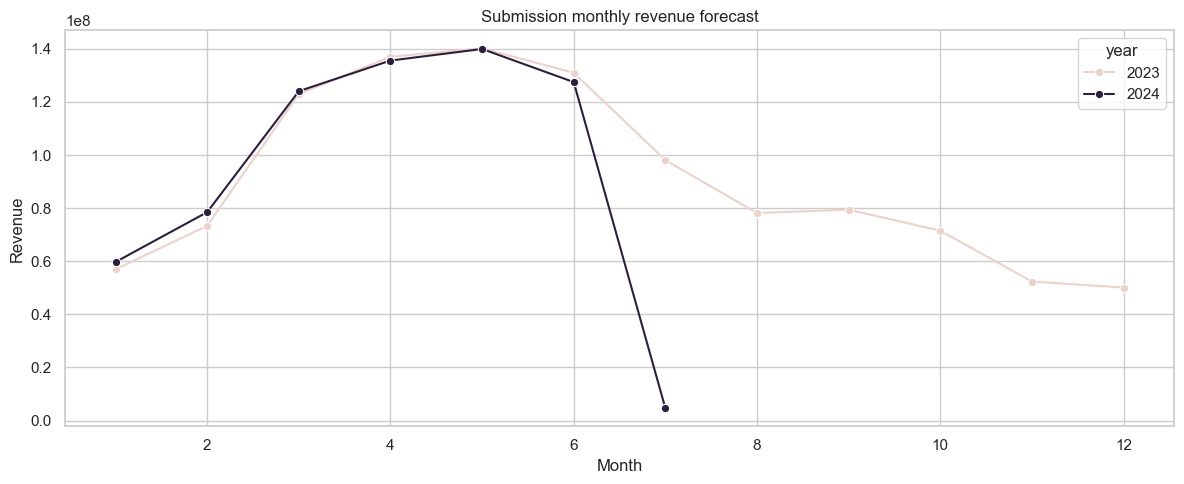

In [46]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=submission_monthly, x="month", y="Revenue", hue="year", marker="o")
plt.title("Submission monthly revenue forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()

## 8. Conclusions

- The current canonical pipeline trains boosted daily-revenue forecasters on log `Revenue` and writes the upload file to `submissions/submission.csv`.
- The primary production artifact remains the calibrated XGBoost top-auxiliary model unless a newer validation/Kaggle run shows another model is stronger.
- Auxiliary tables stop before the 2023-2024 forecast horizon, so they are converted into leakage-safe priors such as long lags, seasonal projections, commercial seasonality scores, and historical rolling/ewm signals.
- The notebook intentionally skips optional auxiliary benchmark files when they are not present, instead of failing on stale artifacts.
- Primary upload file: `submissions/submission.csv`.